# Probability from Data (Titanic Dataset)

Today we will:

- Treat a dataset as a sample space
- Define events as subsets of rows
- Estimate probabilities from data
- Interpret columns as random variables

## Step 1: Load the dataset

Each row will represent one outcome.

In [5]:
import pandas as pd

df = pd.read_csv("./data/titanic.csv") # Read csv into a pandas dataframe
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Step 2: What does this table represent?

- Each row = one passenger (one outcome)
- Columns = properties of that outcome

We will treat this as our sample space.

(Explore how to get info from a dataframe - shape -> number of passengers, all column labels and possible values)

In [14]:
df.shape # Gives shape in (rows, columns)
N_passengers = df.shape[0]
print(f'N_passengers: {N_passengers}')
for col in df.columns:
    print(f"{col}: {df[col].unique()}")

N_passengers: 891
survived: [0 1]
pclass: [3 1 2]
sex: ['male' 'female']
age: [22.   38.   26.   35.     nan 54.    2.   27.   14.    4.   58.   20.
 39.   55.   31.   34.   15.   28.    8.   19.   40.   66.   42.   21.
 18.    3.    7.   49.   29.   65.   28.5   5.   11.   45.   17.   32.
 16.   25.    0.83 30.   33.   23.   24.   46.   59.   71.   37.   47.
 14.5  70.5  32.5  12.    9.   36.5  51.   55.5  40.5  44.    1.   61.
 56.   50.   36.   45.5  20.5  62.   41.   52.   63.   23.5   0.92 43.
 60.   10.   64.   13.   48.    0.75 53.   57.   80.   70.   24.5   6.
  0.67 30.5   0.42 34.5  74.  ]
sibsp: [1 0 3 4 2 5 8]
parch: [0 1 2 5 3 4 6]
fare: [  7.25    71.2833   7.925   53.1      8.05     8.4583  51.8625  21.075
  11.1333  30.0708  16.7     26.55    31.275    7.8542  16.      29.125
  13.      18.       7.225   26.       8.0292  35.5     31.3875 263.
   7.8792   7.8958  27.7208 146.5208   7.75    10.5     82.1708  52.
   7.2292  11.2417   9.475   21.      41.5792  15.5     21.

## Step 3: Define events

Let:

- A = passenger is female
- B = passenger is in first class
- C = passenger survived

In [16]:
aa = df["sex"] == "female"
bb = df["class"] == "First"
cc = df["survived"] == 1

## Step 4: Estimate probabilities

Probability ≈ fraction of rows satisfying a condition

In [24]:
print(f'P(a) = {aa.mean():.2%}')
print(f'P(b) = {bb.mean():.2%}')
print(f'P(c) = {cc.mean():.2%}')

P(a) = 35.24%
P(b) = 24.24%
P(c) = 38.38%


## Step 5: Intersection (AND)

A ∩ B = female AND first class

In [29]:
# print(aa & bb)
print(f'P(A ∩ B): {(aa & bb).mean()}')

P(A ∩ B): 0.10549943883277217


## Step 6: Union (OR)

A ∪ B = female OR first class

In [33]:
print(f'P(A U B): {(aa | bb).mean()}')

P(A U B): 0.489337822671156


## Step 7: Conditional probability

P(C | A) = probability of survival among females

In [37]:
print((aa & cc).mean() / aa.mean())
print(f"P(C | A) ≈ {cc[aa].mean():.2%}") # Nice shortcut thanks to dataframes

0.7420382165605095
P(C | A) ≈ 74.20%


## Step 8: Columns as random variables

A random variable assigns a value to each outcome.

Examples:
- survived (0 or 1)
- class (First, Second, Third)
- who (man, woman, child)

## Step 9: Estimate a PMF from data

We count how often each value occurs.

Relative frequency ≈ probability

Text(0, 0.5, 'probability')

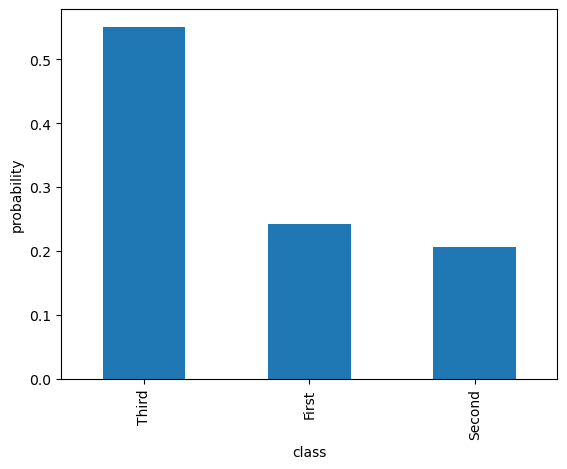

In [46]:
import matplotlib.pyplot as plt
df["class"].value_counts(normalize=True)
ax = df["class"].value_counts(normalize=True).plot(kind="bar")
ax.set_ylabel('probability')

## Summary

- Events = subsets of rows
- Probability ≈ fraction of rows
- Random variables = columns
- PMFs = relative frequencies